Actividad 1: Regresión Lineal Simple
Objetivo: Predecir el salario basándose en los años de experiencia utilizando un modelo de regresión lineal simple.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Cargar el dataset
try:
    data = pd.read_csv('Salary_Data.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo Salary_Data.csv en la carpeta actual.")

Dataset cargado exitosamente.


Exploración de los Datos (EDA)
Visualizamos cómo se distribuyen los datos para entender la relación entre la experiencia y el salario antes de aplicar el modelo.

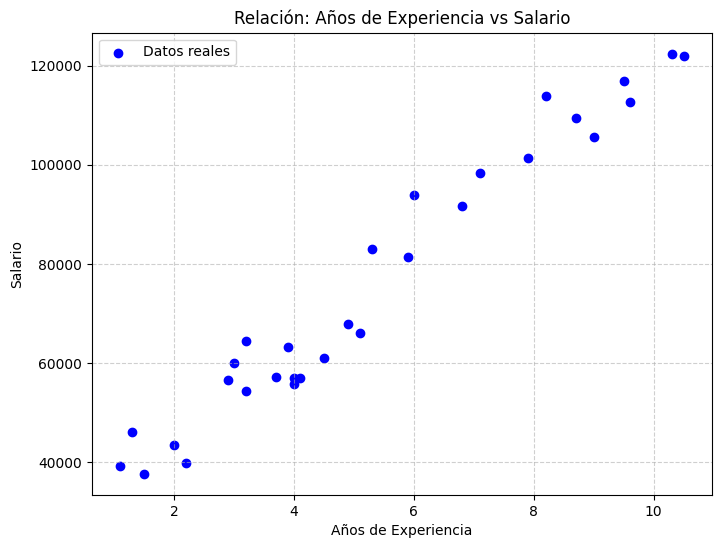

In [11]:
# GRAFICO INICIAL
# Definimos variables (X: Años experiencia, y: Salario)
X = data[['YearsExperience']]
y = data['Salary']

# Gráfico de dispersión inicial
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Datos reales')
plt.title('Relación: Años de Experiencia vs Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Modelado de Datos
Dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar que nuestro modelo sea capaz de aprender patrones y no solo memorizar los datos.

In [12]:
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred = regressor.predict(X_test)

Evaluación del Modelo
Analizamos la precisión del modelo mediante métricas de error y visualizamos la recta de regresión que el modelo ha trazado.

--- Resultados del Modelo ---
Coeficiente (Pendiente): 9423.82
Intercepto: 25321.58
Error Cuadrático Medio (MSE): 49830096.86
Error Absoluto Medio (MAE): 6286.45
Puntuación R2: 0.9024


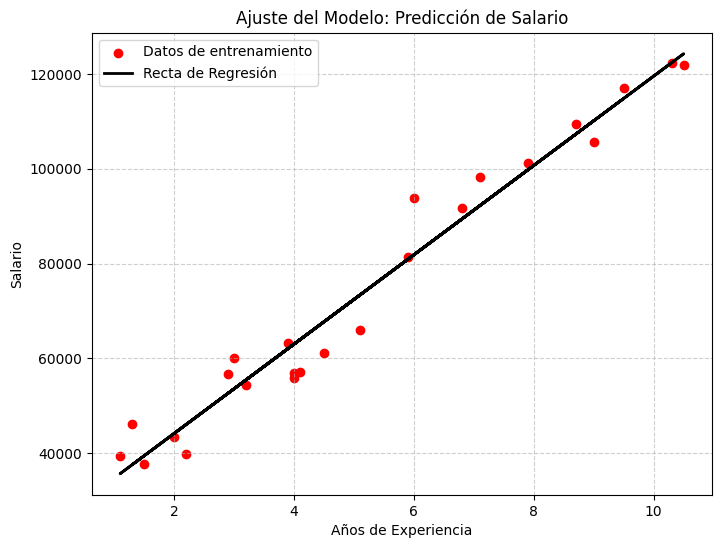

In [16]:
# Impresión de métricas
print("--- Resultados del Modelo ---")
# Accedemos al primer elemento de regressor.coef_ para que el formateo sea correcto
print(f"Coeficiente (Pendiente): {regressor.coef_[0]:.2f}") 
print(f"Intercepto: {regressor.intercept_:.2f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Error Absoluto Medio (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Puntuación R2: {r2_score(y_test, y_pred):.4f}")

# Visualización final: La línea de regresión vs los puntos reales
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='red', label='Datos de entrenamiento')
plt.plot(X_train, regressor.predict(X_train), color='black', linewidth=2, label='Recta de Regresión')
plt.title('Ajuste del Modelo: Predicción de Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()